# Sprint 1 exploration: Greenhouse **pilot** corpus (Section B)

**Scope and caveats, read first**

* **Pilot only:** 5 employers (Duolingo, Robinhood, Recursion Pharmaceuticals, Oura, Figma) from one
  snapshot, `20261006T171338Z`. The board list is a proposal pending Section A. Nothing here
  describes the job market in general.
* **Industry labels** are *team-assigned* per employer (`industry_source` in `config/boards.yaml`),
  so "postings by industry" is the same as "postings by employer" in this pilot.
* **Data:** `data/processed/taxonomy_pilot.sqlite`, opened **read-only**. Every query is filtered
  to the snapshot below.
* **Derived features** (seniority, detected language, near-duplicate candidates) come from
  `src/derive_features.py`. They are written to separate files and never to the `postings` table.
* **Two denominators:** **all rows** (470, flagged rows included) and **usable rows**
  (`exclusion_reason` empty). Every table states which one it uses.

In [1]:
import hashlib, json, sqlite3, sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import derive_features as df_mod

SNAPSHOT_ID = "20261006T171338Z"
DB_PATH = ROOT / "data" / "processed" / "taxonomy_pilot.sqlite"
RAW_DIR = ROOT / "data" / "raw" / "greenhouse" / SNAPSHOT_ID
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

# Fingerprint the database and raw files before any analysis.
HASHES_BEFORE = {p.relative_to(ROOT).as_posix(): sha256(p) for p in [DB_PATH, *sorted(RAW_DIR.glob("*.json"))]}
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)
print(f"snapshot={SNAPSHOT_ID}  files fingerprinted={len(HASHES_BEFORE)}")

snapshot=20261006T171338Z  files fingerprinted=6


In [2]:
# Read-only connection; every query below is filtered with snapshot_id = :snap.
conn = sqlite3.connect(f"file:{DB_PATH.as_posix()}?mode=ro", uri=True)

def q(sql, **params):
    return pd.read_sql_query(sql, conn, params={"snap": SNAPSHOT_ID, **params})

posts = q("SELECT * FROM postings WHERE snapshot_id = :snap ORDER BY posting_id")
usable = q("SELECT * FROM usable_postings WHERE snapshot_id = :snap ORDER BY posting_id")
for col in ("departments", "offices"):
    posts[col] = posts[col].map(json.loads)
    usable[col] = usable[col].map(json.loads)
posts["is_usable"] = posts["exclusion_reason"].eq("")
N_ALL, N_USABLE = len(posts), len(usable)
assert posts["snapshot_id"].eq(SNAPSHOT_ID).all() and usable["snapshot_id"].eq(SNAPSHOT_ID).all()
assert N_USABLE == posts["is_usable"].sum()
print(f"all rows = {N_ALL}, usable rows = {N_USABLE}, flagged rows = {N_ALL - N_USABLE}")

all rows = 470, usable rows = 468, flagged rows = 2


In [3]:
# Chart style: one series hue, ink-coloured text, recessive hairline grid, thin bars.
SERIES = "#2a78d6"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
matplotlib.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 10, "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": INK_2, "ytick.color": INK, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})

def hbar(labels, values, title, xlabel, path, fmt="{:,}", note=None):
    fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(labels) + 1.2))
    y = range(len(labels))
    ax.barh(list(y), values, height=0.5, color=SERIES)
    ax.set_yticks(list(y), labels)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    vmax = max(values) if len(values) else 1
    for yi, v in zip(y, values):
        ax.text(v + vmax * 0.01, yi, fmt.format(v), va="center", color=INK, fontsize=9)
    ax.set_xlim(0, vmax * 1.18 if vmax else 1)
    if note:
        # Below the x-axis label, so it never collides with tick labels.
        ax.annotate(note, xy=(0, 0), xycoords="axes fraction", xytext=(0, -44),
                    textcoords="offset points", color=INK_2, fontsize=8, ha="left", va="top")
    fig.savefig(path)
    plt.show()

## 1. Total, usable and flagged postings

In [4]:
reasons = posts.loc[~posts["is_usable"], ["posting_id", "company_name", "title", "exclusion_reason", "is_placeholder"]]
summary = pd.DataFrame({
    "count": [N_ALL, N_USABLE, N_ALL - N_USABLE],
    "share of all rows": [1.0, N_USABLE / N_ALL, (N_ALL - N_USABLE) / N_ALL],
}, index=["all rows", "usable rows", "flagged rows (kept, excluded from usable)"])
display(summary.style.format({"share of all rows": "{:.1%}"}))
display(reasons)

,count,share of all rows
all rows,470,100.0%
usable rows,468,99.6%
"flagged rows (kept, excluded from usable)",2,0.4%


,posting_id,company_name,title,exclusion_reason,is_placeholder
299,greenhouse:recursionpharmaceuticals:3955652,Recursion Pharmaceuticals,Don't see what you're looking for?,placeholder_title:dont_see_role,1
300,greenhouse:recursionpharmaceuticals:7540026,Recursion Pharmaceuticals,Interested in an internship?,placeholder_text:join_talent_pool,1


## 2. Postings by company and industry, and employer concentration

company_name,industry,industry_source,all_rows,usable_rows,share_of_all_rows,share_of_usable_rows
Figma,Software,team-assigned pilot label (primary product); see figma.com/careers,159,159,33.8%,34.0%
Robinhood,Financial services,team-assigned pilot label (primary product); see careers.robinhood.com,159,159,33.8%,34.0%
Oura,Consumer health technology,team-assigned pilot label (primary product); see ouraring.com/careers,80,80,17.0%,17.1%
Duolingo,Education technology,team-assigned pilot label (primary product); see careers.duolingo.com,60,60,12.8%,12.8%
Recursion Pharmaceuticals,Biotechnology,team-assigned pilot label (primary product); see recursion.com/careers,12,10,2.6%,2.1%


Top-2 employer share of usable rows: 67.9%   HHI (usable shares): 0.277  (1/5 = 0.200 would be perfectly even across 5 employers)
Industry labels are team-assigned per employer, so each industry here has exactly one employer.


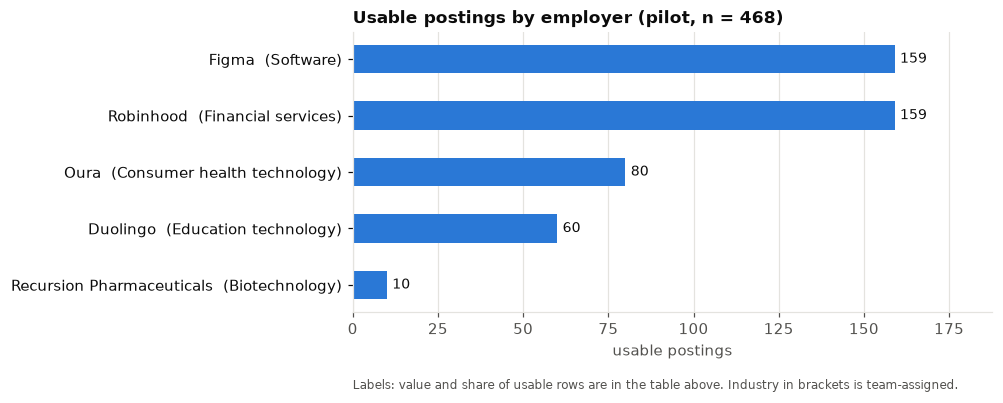

In [5]:
by_co = (posts.groupby(["company_name", "industry", "industry_source"])
         .agg(all_rows=("posting_id", "size"), usable_rows=("is_usable", "sum")).reset_index()
         .sort_values("all_rows", ascending=False))
by_co["share_of_all_rows"] = by_co["all_rows"] / N_ALL
by_co["share_of_usable_rows"] = by_co["usable_rows"] / N_USABLE
hhi = float((by_co["share_of_usable_rows"] ** 2).sum())
top2 = float(by_co["share_of_usable_rows"].nlargest(2).sum())
display(by_co.style.format({"share_of_all_rows": "{:.1%}", "share_of_usable_rows": "{:.1%}"}).hide(axis="index"))
print(f"Top-2 employer share of usable rows: {top2:.1%}   HHI (usable shares): {hhi:.3f}  "
      f"(1/5 = 0.200 would be perfectly even across 5 employers)")
print("Industry labels are team-assigned per employer, so each industry here has exactly one employer.")
hbar([f"{c}  ({i})" for c, i in zip(by_co.company_name, by_co.industry)],
     list(by_co.usable_rows), "Usable postings by employer (pilot, n = %d)" % N_USABLE,
     "usable postings", FIG_DIR / "fig_postings_by_company.png",
     note="Labels: value and share of usable rows are in the table above. Industry in brackets is team-assigned.")

## 3. Departments and locations (all rows)

In [6]:
dept = posts[["company_name", "departments"]].explode("departments")
dept_counts = dept["departments"].value_counts()
print(f"rows with no department: {(posts['departments'].str.len() == 0).sum()} / {N_ALL}")
print(f"distinct department names: {dept_counts.size}  (names are employer-specific, not harmonised)")
per_co = posts.assign(n=posts["departments"].str.len()).groupby("company_name").agg(
    distinct_departments=("departments", lambda s: len({d for lst in s for d in lst})),
    rows=("posting_id", "size"))
display(per_co)
display(dept_counts.head(15).rename("rows (all)").to_frame())

rows with no department: 2 / 470
distinct department names: 96  (names are employer-specific, not harmonised)


,distinct_departments,rows
company_name,,
Duolingo,19,60
Figma,13,159
Oura,13,80
Recursion Pharmaceuticals,4,12
Robinhood,58,159


,rows (all)
departments,
Sales,52
Engineering,32
Design,23
Business Operations,19
Supply Chain,17
Software Engineering,15
Hardware,15
ENG Infrastructure,13
Marketing,12


In [7]:
loc = posts["location"].fillna("(missing)")
multi = loc.str.contains(r";|•", regex=True)
remote = loc.str.contains("remote", case=False)
print(f"distinct location strings: {loc.nunique()}   missing: {(loc == '(missing)').sum()} / {N_ALL}")
print(f"multi-location strings (contain ';' or '•'): {multi.sum()} / {N_ALL} ({multi.mean():.1%})")
print(f"mention 'remote': {remote.sum()} / {N_ALL} ({remote.mean():.1%})")
print("Location strings are free text with employer-specific formats; no geocoding was done.")
display(loc.value_counts().head(15).rename("rows (all)").to_frame())
offices = posts[["offices"]].explode("offices")["offices"].value_counts()
display(offices.head(10).rename("rows (all), office names").to_frame())

distinct location strings: 63   missing: 0 / 470
multi-location strings (contain ';' or '•'): 212 / 470 (45.1%)
mention 'remote': 35 / 470 (7.4%)
Location strings are free text with employer-specific formats; no geocoding was done.


,rows (all)
location,
"San Francisco, CA • New York, NY • United States",88
"Hybrid - San Francisco, California",39
"Menlo Park, CA; New York, NY",37
"New York, NY; Pittsburgh, PA",27
"New York, NY",25
"Menlo Park, CA",23
"London, England",21
Remote - United States,19
"Toronto, Canada",19


,"rows (all), office names"
offices,
"New York, NY",120
US,107
"Menlo Park, CA",97
Canada,53
"San Francisco, CA, United States",44
"Toronto, Canada",39
"London, UK",33
"Pittsburgh, PA",32
"Bellevue, WA",32


## 4. Description length (word count of `clean_text`)

,all rows,usable rows
count,470.0,468.0
mean,930.0,931.0
std,185.0,185.0
min,492.0,492.0
10%,704.0,704.0
25%,797.0,798.0
50%,927.0,927.0
75%,1026.0,1026.0
90%,1141.0,1141.0
max,1665.0,1665.0


,count,min,25%,50%,75%,max
company_name,,,,,,
Duolingo,60.0,492.0,653.0,715.0,821.0,992.0
Figma,159.0,626.0,796.0,964.0,1028.0,1291.0
Oura,80.0,690.0,968.0,1041.0,1203.0,1665.0
Recursion Pharmaceuticals,10.0,1009.0,1184.0,1258.0,1327.0,1440.0
Robinhood,159.0,578.0,818.0,896.0,966.0,1346.0


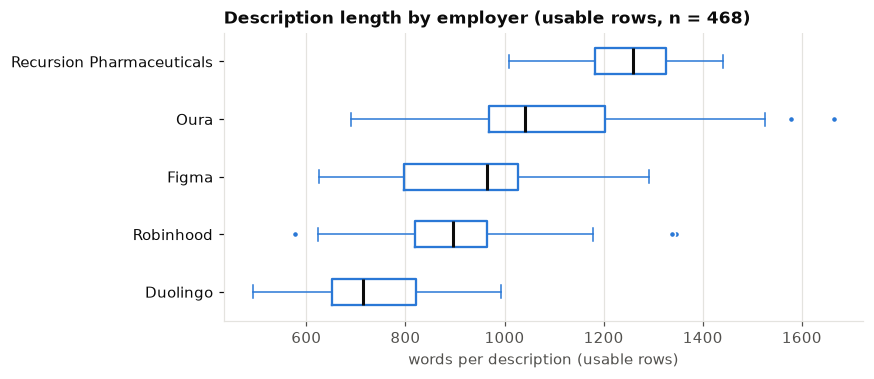

Word counts include boilerplate (benefits, EEO, company intro); they are not requirement-section lengths.


In [8]:
wc = pd.DataFrame({
    "all rows": posts["word_count"].describe(percentiles=[.1, .25, .5, .75, .9]),
    "usable rows": usable["word_count"].describe(percentiles=[.1, .25, .5, .75, .9]),
}).round(0)
display(wc)
display(usable.groupby("company_name")["word_count"].describe()[["count", "min", "25%", "50%", "75%", "max"]].round(0))

order = usable.groupby("company_name")["word_count"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(7.5, 3.4))
data = [usable.loc[usable.company_name == c, "word_count"] for c in order]
ax.boxplot(data, orientation="horizontal", widths=0.45, showfliers=True,
           medianprops={"color": INK, "linewidth": 2}, boxprops={"color": SERIES, "linewidth": 1.5},
           whiskerprops={"color": SERIES}, capprops={"color": SERIES},
           flierprops={"marker": "o", "markersize": 4, "markerfacecolor": SERIES, "markeredgecolor": "white"})
ax.set_yticks(range(1, len(order) + 1), order)
ax.grid(axis="y", visible=False)
ax.set_xlabel("words per description (usable rows)")
ax.set_title(f"Description length by employer (usable rows, n = {N_USABLE})")
fig.savefig(FIG_DIR / "fig_word_count_by_company.png")
plt.show()
print("Word counts include boilerplate (benefits, EEO, company intro); they are not requirement-section lengths.")

## 5. Missing-field rates (all rows)

,missing (all rows),rate (of 470)
internal_job_id,2,0.4%
source_company_name,0,0.0%
title,0,0.0%
location,0,0.0%
departments,2,0.4%
offices,2,0.4%
raw_text,0,0.0%
clean_text,0,0.0%
absolute_url,0,0.0%
source_updated_at,0,0.0%


Fields with any missing values: internal_job_id, departments, offices
Not available from Greenhouse at all (so not in this table): seniority, industry (team-assigned instead).


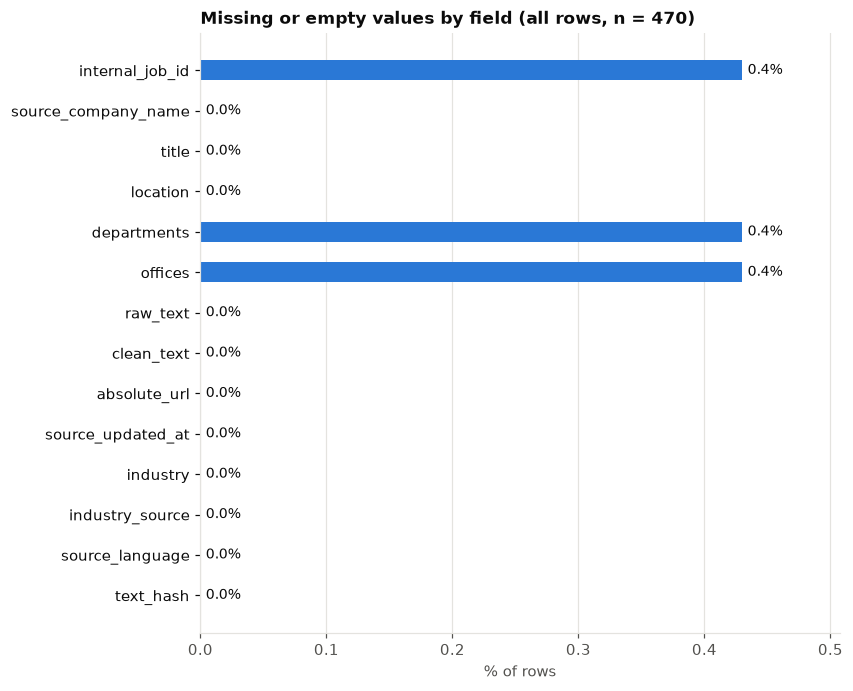

In [9]:
def missing(col):
    s = posts[col]
    if col in ("departments", "offices"):
        return s.str.len().eq(0)
    return s.isna() | s.astype(str).str.strip().eq("")
fields = ["internal_job_id", "source_company_name", "title", "location", "departments", "offices",
          "raw_text", "clean_text", "absolute_url", "source_updated_at", "industry", "industry_source",
          "source_language", "text_hash"]
miss = pd.DataFrame({"missing (all rows)": [int(missing(f).sum()) for f in fields]}, index=fields)
miss["rate (of %d)" % N_ALL] = miss.iloc[:, 0] / N_ALL
display(miss.style.format({miss.columns[1]: "{:.1%}"}))
nonzero = miss[miss.iloc[:, 0] > 0]
print("Fields with any missing values:", ", ".join(nonzero.index) or "none")
print("Not available from Greenhouse at all (so not in this table): seniority, industry (team-assigned instead).")
hbar(list(miss.index), [round(100 * r, 2) for r in miss.iloc[:, 1]],
     f"Missing or empty values by field (all rows, n = {N_ALL})", "% of rows",
     FIG_DIR / "fig_missing_fields.png", fmt="{:.1f}%")

## 6. Exact duplicates vs repeated titles (kept separate)

In [10]:
with_text = posts["text_hash"].notna()
exact = posts["is_duplicate_of"].notna()
print(f"exact duplicates (normalized clean_text): {exact.sum()} of {with_text.sum()} rows with text "
      f"= {exact.sum() / with_text.sum():.1%}  (all rows: {exact.sum()}/{N_ALL})")

posts["title_norm"] = posts["title"].map(df_mod.normalize_title)
grp = posts.groupby(["board_token", "title_norm"])
rep = grp.agg(rows=("posting_id", "size"), distinct_texts=("text_hash", "nunique"),
              locations=("location", lambda s: " · ".join(map(str, s)))).reset_index()
rep = rep[rep["rows"] > 1].sort_values(["rows", "board_token"], ascending=[False, True])
print(f"repeated-title groups (same board + same normalized title): {len(rep)} groups, {rep['rows'].sum()} rows")
print(f"  of which have identical text in every row: {(rep['distinct_texts'] == 1).sum()}  "
      "(repeated titles are NOT treated as duplicates)")
display(rep.reset_index(drop=True))

exact duplicates (normalized clean_text): 0 of 470 rows with text = 0.0%  (all rows: 0/470)


repeated-title groups (same board + same normalized title): 13 groups, 27 rows
  of which have identical text in every row: 0  (repeated titles are NOT treated as duplicates)


,board_token,title_norm,rows,distinct_texts,locations
0,robinhood,"product marketing manager, international",3,3,"London, UK · Luxembourg, Luxembourg · Ljubljana, Slovenia"
1,duolingo,"proctor quality and learning manager, scaling operations",2,2,"New York, NY; Pittsburgh, PA · London, England"
2,duolingo,"senior creative director, marketing",2,2,"New York, NY · London, England"
3,duolingo,senior product designer,2,2,"New York, NY; Pittsburgh, PA · Beijing, China"
4,recursionpharmaceuticals,"executive director, clinical pharmacology/pharmacometrics",2,2,Remote Opportunity - United States · Remote Opportunity - United Kingdom
5,robinhood,"engineering manager, international",2,2,"New York, NY · Toronto, Canada"
6,robinhood,financial operations manager,2,2,"Singapore · Lake Mary, FL; New York, NY"
7,robinhood,"senior software engineer, custody services",2,2,"London, UK · Ljubljana, Slovenia"
8,robinhood,"senior software engineer, prime",2,2,"London, UK · Ljubljana, Slovenia"
9,robinhood,"senior software engineer, tokenization",2,2,"Menlo Park, CA; New York, NY · Toronto, Canada"


## 7. Placeholder / general-interest exclusions

In [11]:
ph = posts[posts["is_placeholder"] == 1][["posting_id", "company_name", "title", "exclusion_reason", "word_count"]]
display(ph)
print(f"placeholders: {len(ph)} of {N_ALL} rows ({len(ph) / N_ALL:.1%}); all are kept in the database "
      "and excluded only from usable_postings. The rules are heuristic (title patterns + two narrow "
      "description phrases).")

,posting_id,company_name,title,exclusion_reason,word_count
299,greenhouse:recursionpharmaceuticals:3955652,Recursion Pharmaceuticals,Don't see what you're looking for?,placeholder_title:dont_see_role,733
300,greenhouse:recursionpharmaceuticals:7540026,Recursion Pharmaceuticals,Interested in an internship?,placeholder_text:join_talent_pool,739


placeholders: 2 of 470 rows (0.4%); all are kept in the database and excluded only from usable_postings. The rules are heuristic (title patterns + two narrow description phrases).


## 8. Derived features (separate from the immutable `postings` table)

`derive_features.run_all` reads the same database read-only and writes:

* `data/processed/derived/seniority_<snapshot>.csv` (rule-based, using `config/seniority_rules.yaml`)
* `data/processed/derived/language_<snapshot>.csv` (local `lingua` detector, no LLM, no API)
* `reports/sprint1_near_duplicate_candidates_<snapshot>.csv` (candidate pairs for manual review)

In [12]:
derived = df_mod.run_all(DB_PATH, SNAPSHOT_ID, root=ROOT)
sen = pd.DataFrame(derived["seniority"])
lang = pd.DataFrame(derived["language"])
pairs = pd.DataFrame(derived["pairs"])
for k, p in derived["paths"].items():
    print(f"{k:<10} -> {p.relative_to(ROOT).as_posix()}")
print(f"seniority rules v{derived['rules'].version} (sha256 {derived['rules'].sha256[:12]}…); "
      f"language detector {lang['detector'].iloc[0]} {lang['detector_version'].iloc[0]}")

seniority  -> data/processed/derived/seniority_20261006T171338Z.csv
language   -> data/processed/derived/language_20261006T171338Z.csv
pairs      -> reports/sprint1_near_duplicate_candidates_20261006T171338Z.csv
seniority rules v0.1.0 (sha256 a599f7a277f1…); language detector lingua-language-detector 2.2.0


### 8a. Seniority (rule-based, from title wording only)

Rules are evaluated in order and the first match wins. Every other matching rule is kept in
`other_matches`. **Limitations:**

* Titles signal seniority inconsistently across companies.
* "manager" does not prove people management. Common individual-contributor role names
  ("Product Manager", "Program Manager", …) are excluded from the manager rule.
* "Account Executive" is a sales role, not an executive level.
* Titles with no marker are labelled `unknown`. We do **not** assume they are mid-level.
* `ambiguous` covers "Lead" and explicit level ranges such as "Senior/Software Engineer II".
* Labels were not validated against ground truth.

,all rows,usable rows,share of usable
seniority_label,,,
intern,37,36,7.7%
entry,2,2,0.4%
mid,2,2,0.4%
senior,101,101,21.6%
staff_principal,48,48,10.3%
manager,68,68,14.5%
director,32,32,6.8%
executive,6,6,1.3%
ambiguous,14,14,3.0%


seniority_label,intern,entry,mid,senior,staff_principal,manager,director,executive,ambiguous,unknown
company_name,,,,,,,,,,
Duolingo,2,0,2,23,6,9,6,2,5,5
Figma,8,1,0,7,0,31,10,0,0,102
Oura,0,0,0,29,12,13,9,1,2,14
Recursion Pharmaceuticals,0,0,0,3,0,0,5,2,0,0
Robinhood,26,1,0,39,30,15,2,1,7,38


rows where another rule also matched (see other_matches): 34 / 470


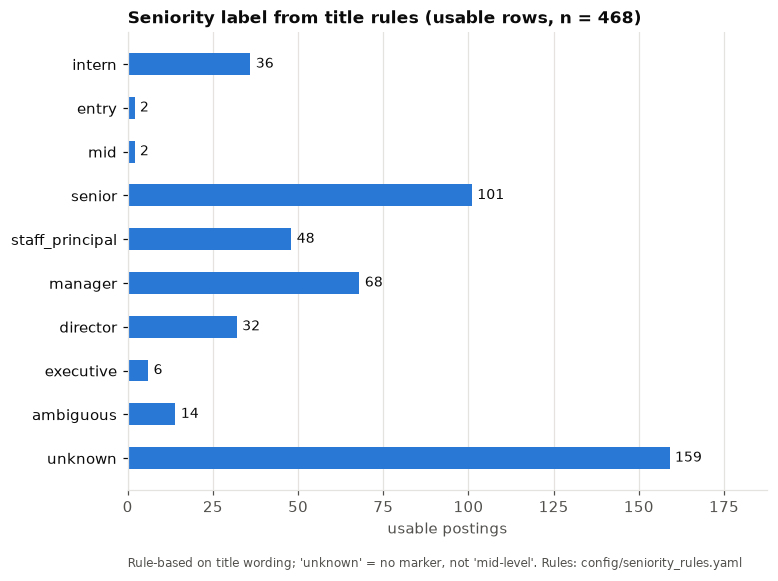

In [13]:
labels = list(derived["rules"].labels)
sen = sen.merge(posts[["posting_id", "company_name", "is_usable"]], on="posting_id")
counts = pd.DataFrame({
    "all rows": sen["seniority_label"].value_counts().reindex(labels, fill_value=0),
    "usable rows": sen[sen.is_usable]["seniority_label"].value_counts().reindex(labels, fill_value=0),
})
counts["share of usable"] = counts["usable rows"] / N_USABLE
display(counts.style.format({"share of usable": "{:.1%}"}))
display(pd.crosstab(sen[sen.is_usable]["company_name"], sen[sen.is_usable]["seniority_label"])
        .reindex(columns=labels, fill_value=0))
print(f"rows where another rule also matched (see other_matches): {(sen['other_matches'] != '').sum()} / {N_ALL}")
hbar(labels, list(counts["usable rows"]), f"Seniority label from title rules (usable rows, n = {N_USABLE})",
     "usable postings", FIG_DIR / "fig_seniority.png",
     note="Rule-based on title wording; 'unknown' = no marker, not 'mid-level'. Rules: config/seniority_rules.yaml")

In [14]:
# Manual-review sample: fixed seed, so the same rows come back on every run.
sample = sen.sample(20, random_state=7)[["title", "seniority_label", "rule_id", "other_matches"]]
display(sample.reset_index(drop=True))
display(sen[sen["other_matches"] != ""][["title", "seniority_label", "other_matches"]].head(15).reset_index(drop=True))

,title,seniority_label,rule_id,other_matches
0,"Director, Partnerships & Enterprise International Growth",director,director,
1,"Logistics Manager, Americas Retail Operations",manager,manager,
2,Executive Assistant to the CEO,unknown,,
3,"Director, Technology Business Operations",director,director,
4,"Senior Product Manager, Crypto Wallet",senior,senior,
5,Senior Offensive Security Engineer,senior,senior,
6,"Staff Software Engineer, Brokerage Infra",staff_principal,staff_principal,
7,Crypto Risk Lead,ambiguous,lead,
8,"Product Marketing Manager, International",unknown,,
9,Technical Quality Specialist,unknown,,


,title,seniority_label,other_matches
0,"Senior/Software Engineer II, Backend",ambiguous,senior:senior;mid:mid
1,"Senior Director of Engineering, New Subjects",director,senior:senior
2,"Senior/Software Engineer II, Android",ambiguous,senior:senior;mid:mid
3,"Senior Data Science Manager, User Growth",manager,senior:senior
4,"Senior Engineering Manager, Product",manager,senior:senior
5,Senior Marketing Analytics Manager,manager,senior:senior
6,"Senior Engineering Manager, AI Platform",manager,senior:senior
7,"Associate Product Manager, Intern",intern,entry:entry
8,"Senior Manager, Enterprise Sales (London, United Kingdom)",manager,senior:senior
9,"Senior Sourcing Manager, Mechanicals",manager,senior:senior


### 8b. Language: detected (local) vs `source_language` (employer-set)

`source_language` is Greenhouse's employer-set field and is preserved unchanged. `detected_language`
is the language covering the most words across paragraphs of 25 or more words. lingua's
whole-text result is recorded too. The two are kept separate because, on mixed-language
text, the whole-text label can follow the minority language. A row is **uncertain** if any of
these holds: whole-text confidence below 0.90, a margin below 0.25, fewer than 30 words, a
disagreement between the paragraph and whole-text labels, or any paragraph in another language.

In [15]:
lang = lang.merge(posts[["posting_id", "company_name", "title", "location", "is_usable"]], on="posting_id")
display(pd.crosstab(lang["source_language"].fillna("(missing)"), lang["detected_language"].fillna("(none)"),
                    margins=True, margins_name="total (all rows)"))
unc = lang[lang["is_uncertain"]]
dis = lang[lang["agrees_with_source"] == False]
print(f"uncertain: {len(unc)} / {N_ALL}   disagreements with source_language: {len(dis)} / {N_ALL}")
print(f"min whole-text confidence: {lang['whole_text_confidence'].min():.4f}   "
      f"min primary_share: {lang['primary_share'].min():.4f}   "
      f"rows with other-language paragraphs: {(lang['other_language_paragraphs'] > 0).sum()}")
display(unc[["posting_id", "title", "detected_language", "uncertainty_reason"]])
display(dis[["posting_id", "title", "source_language", "detected_language", "whole_text_confidence"]])

detected_language,en,total (all rows)
source_language,,
en,470,470
total (all rows),470,470


uncertain: 0 / 470   disagreements with source_language: 0 / 470
min whole-text confidence: 1.0000   min primary_share: 1.0000   rows with other-language paragraphs: 0


,posting_id,title,detected_language,uncertainty_reason


,posting_id,title,source_language,detected_language,whole_text_confidence


In [16]:
# Manual inspection sample (fixed seed). Non-US locations are deliberately included, since they are
# the most likely to contain non-English text.
non_us = lang[~lang["location"].fillna("").str.contains(r"\bUS\b|United States|, [A-Z]{2}\b|California|Remote - United States", regex=True)]
manual = pd.concat([lang.sample(6, random_state=11), non_us.sample(min(6, len(non_us)), random_state=11)]).drop_duplicates("posting_id")
manual = manual.merge(posts[["posting_id", "clean_text"]], on="posting_id")
manual["text_start"] = manual["clean_text"].str.replace(r"\s+", " ", regex=True).str.slice(0, 160)
display(manual[["posting_id", "location", "source_language", "detected_language", "whole_text_confidence", "text_start"]])

,posting_id,location,source_language,detected_language,whole_text_confidence,text_start
0,greenhouse:figma:6124232004,"London, England",en,en,1.0,Figma is growing our team of passionate creatives and builders on a mission ...
1,greenhouse:oura:4301714009,"Remote - San Francisco, California",en,en,1.0,Our mission at Oura is to empower every person to own their inner potential....
2,greenhouse:robinhood:8003233,"Menlo Park, CA; New York, NY",en,en,1.0,Join us in building the future of finance. Our mission is to democratize fin...
3,greenhouse:robinhood:8088455,"Toronto, Canada",en,en,1.0,Join us in building the future of finance. Our mission is to democratize fin...
4,greenhouse:figma:6010279004,"San Francisco, CA • New York, NY • United States",en,en,1.0,Figma is growing our team of passionate creatives and builders on a mission ...
5,greenhouse:duolingo:8806187002,"Pittsburgh, PA",en,en,1.0,Our mission at Duolingo is to develop the best education in the world and ma...
6,greenhouse:duolingo:8702391002,"Beijing, China",en,en,1.0,Our mission at Duolingo is to develop the best education in the world and ma...
7,greenhouse:robinhood:8202146,"Ljubljana, Slovenia",en,en,1.0,Join us in building the future of finance. Our mission is to democratize fin...
8,greenhouse:figma:5756182004,"Tokyo, Japan",en,en,1.0,Figma is growing our team of passionate creatives and builders on a mission ...
9,greenhouse:robinhood:7737164,"Toronto, Canada",en,en,1.0,Join us in building the future of finance. Our mission is to democratize fin...


### 8c. Near-duplicate **candidates** (for review; nothing is excluded)

Candidate groups are built **within one board** from (a) a shared `internal_job_id` or (b) the
same normalized title. **Every pair** in each group is compared, using difflib similarity of
`clean_text` and token Jaccard. **This does not detect every near-duplicate.** It misses, for
example, the same role posted with location-suffixed titles under different internal IDs
(Figma's "Account Executive, Enterprise (Paris, France)" and its variants), and anything across
boards.

candidate pairs: 30  (status = 'candidate' for all; none excluded)


,board_token,basis,pairs
0,duolingo,internal_job_id,3
1,duolingo,internal_job_id+title,2
2,duolingo,title,1
3,recursionpharmaceuticals,internal_job_id+title,1
4,robinhood,internal_job_id,12
5,robinhood,internal_job_id+title,10
6,robinhood,title,1


,pairs
text_similarity,
"(-0.001, 0.6]",2
"(0.6, 0.8]",1
"(0.8, 0.9]",13
"(0.9, 0.95]",3
"(0.95, 0.99]",2
"(0.99, 1.0]",9


,board_token,basis,title_a,title_b,location_a,location_b,text_similarity,token_jaccard,exact_text_match,posting_id_a,posting_id_b
0,duolingo,internal_job_id,Ad Sales Lead - West,Director of Ad Sales - West,Remote - California,Remote - California,0.9990,0.9846,False,greenhouse:duolingo:8705196002,greenhouse:duolingo:8761234002
1,robinhood,internal_job_id+title,"Product Marketing Manager, International","Product Marketing Manager, International","Luxembourg, Luxembourg","Ljubljana, Slovenia",0.9985,0.9949,False,greenhouse:robinhood:8074011,greenhouse:robinhood:8074057
2,duolingo,internal_job_id+title,"Senior Creative Director, Marketing","Senior Creative Director, Marketing","New York, NY","London, England",0.9979,0.9771,False,greenhouse:duolingo:8442932002,greenhouse:duolingo:8442934002
3,duolingo,internal_job_id+title,"Proctor Quality and Learning Manager, Scaling Operations","Proctor Quality and Learning Manager, Scaling Operations","New York, NY; Pittsburgh, PA","London, England",0.9978,0.9800,False,greenhouse:duolingo:8858331002,greenhouse:duolingo:8858333002
4,robinhood,internal_job_id+title,"Product Marketing Manager, International","Product Marketing Manager, International","London, UK","Ljubljana, Slovenia",0.9966,0.9899,False,greenhouse:robinhood:8067556,greenhouse:robinhood:8074057
5,robinhood,internal_job_id+title,"Product Marketing Manager, International","Product Marketing Manager, International","London, UK","Luxembourg, Luxembourg",0.9964,0.9899,False,greenhouse:robinhood:8067556,greenhouse:robinhood:8074011
6,duolingo,title,Senior Product Designer,Senior Product Designer,"New York, NY; Pittsburgh, PA","Beijing, China",0.9956,0.9723,False,greenhouse:duolingo:8489189002,greenhouse:duolingo:8675713002
7,robinhood,internal_job_id+title,"Senior Software Engineer, Custody Services","Senior Software Engineer, Custody Services","London, UK","Ljubljana, Slovenia",0.9952,0.9846,False,greenhouse:robinhood:7648452,greenhouse:robinhood:7648454
8,recursionpharmaceuticals,internal_job_id+title,"Executive Director, Clinical Pharmacology/Pharmacometrics","Executive Director, Clinical Pharmacology/Pharmacometrics",Remote Opportunity - United States,Remote Opportunity - United Kingdom,0.9905,0.9639,False,greenhouse:recursionpharmaceuticals:8234254,greenhouse:recursionpharmaceuticals:8234261
9,robinhood,internal_job_id,"Customer Experience Representative, Concierge","Overnight Customer Experience Representative, Concierge","Denver, CO; Westlake, TX","Denver, CO; Westlake, TX",0.9535,0.9338,False,greenhouse:robinhood:7958748,greenhouse:robinhood:8224805


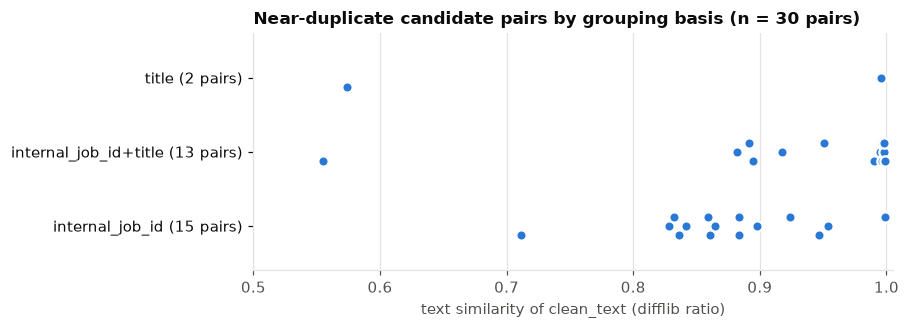

In [17]:
print(f"candidate pairs: {len(pairs)}  (status = 'candidate' for all; none excluded)")
display(pairs.groupby(["board_token", "basis"]).size().rename("pairs").reset_index())
bins = pd.cut(pairs["text_similarity"], [0, .6, .8, .9, .95, .99, 1.0], include_lowest=True)
display(bins.value_counts().sort_index().rename("pairs").to_frame())
display(pairs[["board_token", "basis", "title_a", "title_b", "location_a", "location_b",
               "text_similarity", "token_jaccard", "exact_text_match", "posting_id_a", "posting_id_b"]])

fig, ax = plt.subplots(figsize=(7.5, 2.8))
order_b = ["internal_job_id", "internal_job_id+title", "title"]
for i, b in enumerate(order_b):
    v = pairs.loc[pairs["basis"] == b, "text_similarity"].sort_values()
    offsets = [((k % 3) - 1) * 0.12 for k in range(len(v))]  # fixed offsets separate close dots
    ax.scatter(v, [i + o for o in offsets], s=46, color=SERIES, edgecolor="white", linewidth=1.5, zorder=3)
ax.set_yticks(range(len(order_b)), [f"{b} ({(pairs.basis == b).sum()} pairs)" for b in order_b])
ax.set_ylim(-0.6, len(order_b) - 0.4)
ax.grid(axis="y", visible=False)
ax.set_xlim(0.5, 1.005)
ax.set_xlabel("text similarity of clean_text (difflib ratio)")
ax.set_title(f"Near-duplicate candidate pairs by grouping basis (n = {len(pairs)} pairs)")
fig.savefig(FIG_DIR / "fig_near_duplicate_similarity.png")
plt.show()

## 9. Metrics snapshot and integrity check

In [18]:
metrics = {
    "snapshot_id": SNAPSHOT_ID, "all_rows": N_ALL, "usable_rows": N_USABLE, "flagged_rows": N_ALL - N_USABLE,
    "placeholders": int(posts["is_placeholder"].sum()),
    "exact_duplicates": int(exact.sum()), "rows_with_text": int(with_text.sum()),
    "repeated_title_groups": int(len(rep)), "repeated_title_rows": int(rep["rows"].sum()),
    "employer_usable": dict(zip(by_co.company_name, map(int, by_co.usable_rows))),
    "top2_usable_share": round(top2, 4), "hhi_usable": round(hhi, 4),
    "word_count_usable_median": float(usable["word_count"].median()),
    "word_count_usable_min": int(usable["word_count"].min()), "word_count_usable_max": int(usable["word_count"].max()),
    "missing_fields": {k: int(v) for k, v in miss.iloc[:, 0].items() if v},
    "distinct_locations": int(loc.nunique()), "multi_location_rows": int(multi.sum()), "remote_rows": int(remote.sum()),
    "distinct_departments": int(dept_counts.size),
    "seniority_usable": {k: int(v) for k, v in counts["usable rows"].items()},
    "language_detected": lang["detected_language"].value_counts(dropna=False).to_dict(),
    "language_uncertain": int(len(unc)), "language_disagreements": int(len(dis)),
    "detector": f"{lang['detector'].iloc[0]} {lang['detector_version'].iloc[0]}",
    "seniority_rules_version": derived["rules"].version,
    "near_duplicate_candidate_pairs": int(len(pairs)),
    "near_duplicate_pairs_ge_0_99": int((pairs["text_similarity"] >= 0.99).sum()),
    "near_duplicate_pairs_by_basis": pairs["basis"].value_counts().to_dict(),
}
(ROOT / "reports" / "sprint1_exploration_metrics.json").write_text(json.dumps(metrics, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
conn.close()

HASHES_AFTER = {p.relative_to(ROOT).as_posix(): sha256(p) for p in [DB_PATH, *sorted(RAW_DIR.glob("*.json"))]}
assert HASHES_AFTER == HASHES_BEFORE, "database or raw snapshot changed during analysis!"
print(f"Integrity OK: {len(HASHES_AFTER)} files (database + raw snapshot) byte-identical before and after analysis.")

Integrity OK: 6 files (database + raw snapshot) byte-identical before and after analysis.
